## First Name First Initial Analysis

Amanda Rodgers 

November 8th 

Purpose of file is to find the percentage of correct entity matches this iteration of the model produced within 
certain thresholds.

# Organize ground truth entities in first_initial dataset

In [4]:
import pandas as pd
import numpy as np

In [5]:
# Import first_name_first_inital dataset
clean_data = pd.read_csv('clean_data.csv')

In [6]:
clean_data.head(5)

,unique_id,transaction_id,sender_name,receiver_name,sender_address_full,sender_zipcode,receiver_address_full,receiver_zipcode,transaction_amount
0,1,1,Jessica Obrien,Stephanie Morales,Japan,NaN,"4466 Marc Village, Port Joseph, UT 69096",950.0,266977.82
1,2,2,James Andrews,Elizabeth Mcmahon,NaN,NaN,"900 Webster Street Suite 761, North Mary, TN 8...",718.0,936654.59
2,3,3,Joseph Ross,Sheryl Pope,"773 Sarah Extension Apartment 571, Williamsbur...",NaN,"75403 Raymond Flat Apartment 085, Jenniferstad...",99376.0,648035.39
3,4,4,Heather Smith,Joanne Smith,United States,NaN,"8302 Hicks Point Apartment 917, Kirkshire, MP ...",665.0,609131.01
4,5,5,Anna Elliott,Casey Le,United States,NaN,"1690 Eric Summit Apartment 545, Port Evelyn, I...",NaN,171138.65


In [7]:
# Create a list called keys from the range 899 to 948
keys = list(range(899, 949))
values = list(range(949,999))

# Merge the lists into a dictionary using zip
true_matches = dict(zip(keys, values))

# Need to manually add in these matches
true_matches[2] = 999
true_matches[3] = 1000

# Print the merged dictionary
print(true_matches)

{899: 949, 900: 950, 901: 951, 902: 952, 903: 953, 904: 954, 905: 955, 906: 956, 907: 957, 908: 958, 909: 959, 910: 960, 911: 961, 912: 962, 913: 963, 914: 964, 915: 965, 916: 966, 917: 967, 918: 968, 919: 969, 920: 970, 921: 971, 922: 972, 923: 973, 924: 974, 925: 975, 926: 976, 927: 977, 928: 978, 929: 979, 930: 980, 931: 981, 932: 982, 933: 983, 934: 984, 935: 985, 936: 986, 937: 987, 938: 988, 939: 989, 940: 990, 941: 991, 942: 992, 943: 993, 944: 994, 945: 995, 946: 996, 947: 997, 948: 998, 2: 999, 3: 1000}


In [8]:
# Create dictionary for predicted matches from splink in predictions_first_initial.csv
# Note: we will remove match_weights <= 0 (below zero means not likely a match) 
# Note: we will only keep match_probability above 50% (closer to zero means most likely not a match and closer
# to 1 means most likely a match)

In [9]:
# Import predictions_first_initial.csv
predictions = pd.read_csv('predictions_first_initial.csv')
predictions

,match_weight,match_probability,unique_id_l,unique_id_r,sender_first_name_l,sender_first_name_r,gamma_sender_first_name,tf_sender_first_name_l,tf_sender_first_name_r,bf_sender_first_name,...,gamma_sender_last_name,tf_sender_last_name_l,tf_sender_last_name_r,bf_sender_last_name,bf_tf_adj_sender_last_name,sender_address_full_l,sender_address_full_r,gamma_sender_address_full,bf_sender_address_full,match_key
0,2.136338,0.814693,48,124,Jennifer,Janice,1,0.020,0.001,0.502596,...,4,0.005,0.005,564.910714,0.336336,United States,United States,2,2.422881,1
1,10.213296,0.999158,18,173,Steven,Steven,4,0.007,0.007,188.828094,...,4,0.005,0.005,564.910714,0.336336,United States,United States,2,2.422881,0
2,-0.502287,0.413829,107,180,Joshua,Jessica,0,0.005,0.015,0.012913,...,4,0.002,0.002,564.910714,0.840841,United States,United States,2,2.422881,1
3,-1.779011,0.225636,7,231,Robert,Christopher,0,0.010,0.017,0.012913,...,4,0.002,0.002,564.910714,0.840841,"561 Robles Loop, Thomasville, PA 72004",NaN,-1,1.000000,1
4,-0.502287,0.413829,88,353,William,Kimberly,0,0.006,0.006,0.012913,...,4,0.002,0.002,564.910714,0.840841,United States,United States,2,2.422881,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,-0.739374,0.374609,189,266,Stephanie,Stephanie,4,0.007,0.007,188.828094,...,4,0.029,0.029,564.910714,0.057989,Honduras,United States,0,0.041125,0
160,1.122165,0.685211,236,868,Jennifer,Jennifer,4,0.020,0.020,188.828094,...,4,0.009,0.009,564.910714,0.186854,Angola,United States,0,0.041125,0
161,0.136338,0.523608,62,988,Stanley,S,1,0.001,0.006,0.502596,...,4,0.010,0.010,564.910714,0.168168,United States,United States,2,2.422881,1
162,4.948545,0.968631,4,483,Heather,Heather,4,0.008,0.008,188.828094,...,4,0.029,0.029,564.910714,0.057989,United States,United States,2,2.422881,0


In [10]:
# List all columns in predictions
# Iterate over columns and print each column name
for column in predictions.columns:
    print(column)

match_weight
match_probability
unique_id_l
unique_id_r
sender_first_name_l
sender_first_name_r
gamma_sender_first_name
tf_sender_first_name_l
tf_sender_first_name_r
bf_sender_first_name
bf_tf_adj_sender_first_name
sender_last_name_l
sender_last_name_r
gamma_sender_last_name
tf_sender_last_name_l
tf_sender_last_name_r
bf_sender_last_name
bf_tf_adj_sender_last_name
sender_address_full_l
sender_address_full_r
gamma_sender_address_full
bf_sender_address_full
match_key


In [11]:
# Keep only columns we need in predictions
columns_to_keep = ['match_weight', 'match_probability', 'unique_id_l', 'unique_id_r', 'sender_first_name_l', 'sender_first_name_r', 'sender_last_name_l', 'sender_last_name_r', 'sender_address_full_l', 'sender_address_full_r', 'match_key' ]
predictions = predictions[columns_to_keep]

In [12]:
predictions.head(5)

,match_weight,match_probability,unique_id_l,unique_id_r,sender_first_name_l,sender_first_name_r,sender_last_name_l,sender_last_name_r,sender_address_full_l,sender_address_full_r,match_key
0,2.136338,0.814693,48,124,Jennifer,Janice,Kelly,Kelly,United States,United States,1
1,10.213296,0.999158,18,173,Steven,Steven,Black,Black,United States,United States,0
2,-0.502287,0.413829,107,180,Joshua,Jessica,Blake,Blake,United States,United States,1
3,-1.779011,0.225636,7,231,Robert,Christopher,Price,Price,"561 Robles Loop, Thomasville, PA 72004",NaN,1
4,-0.502287,0.413829,88,353,William,Kimberly,Olson,Olson,United States,United States,1


In [13]:
# Filter the DataFrame to keep only rows with match_weight > 0
filtered_match_weight_predictions = predictions[predictions['match_weight'] > 0]
filtered_match_weight_predictions

,match_weight,match_probability,unique_id_l,unique_id_r,sender_first_name_l,sender_first_name_r,sender_last_name_l,sender_last_name_r,sender_address_full_l,sender_address_full_r,match_key
0,2.136338,0.814693,48,124,Jennifer,Janice,Kelly,Kelly,United States,United States,1
1,10.213296,0.999158,18,173,Steven,Steven,Black,Black,United States,United States,0
35,0.136338,0.523608,767,801,Mary,Mrs,Harris,Harris,United States,United States,1
45,4.780194,0.964885,277,877,Melissa,Alyssa,Brewer,Brewer,United States,United States,1
53,3.610269,0.924313,901,951,Jennifer,J,Deleon,Deleon,Mayotte,Mayotte,1
...,...,...,...,...,...,...,...,...,...,...,...
158,0.780194,0.631996,75,996,Scott,S,White,White,United States,United States,1
160,1.122165,0.685211,236,868,Jennifer,Jennifer,Rodriguez,Rodriguez,Angola,United States,0
161,0.136338,0.523608,62,988,Stanley,S,Harris,Harris,United States,United States,1
162,4.948545,0.968631,4,483,Heather,Heather,Smith,Smith,United States,United States,0


In [14]:
# Filter df to keep only rows with match_probability above 0.5
filtered_predictions = filtered_match_weight_predictions[filtered_match_weight_predictions['match_probability'] > 0.5]
filtered_predictions

,match_weight,match_probability,unique_id_l,unique_id_r,sender_first_name_l,sender_first_name_r,sender_last_name_l,sender_last_name_r,sender_address_full_l,sender_address_full_r,match_key
0,2.136338,0.814693,48,124,Jennifer,Janice,Kelly,Kelly,United States,United States,1
1,10.213296,0.999158,18,173,Steven,Steven,Black,Black,United States,United States,0
35,0.136338,0.523608,767,801,Mary,Mrs,Harris,Harris,United States,United States,1
45,4.780194,0.964885,277,877,Melissa,Alyssa,Brewer,Brewer,United States,United States,1
53,3.610269,0.924313,901,951,Jennifer,J,Deleon,Deleon,Mayotte,Mayotte,1
...,...,...,...,...,...,...,...,...,...,...,...
158,0.780194,0.631996,75,996,Scott,S,White,White,United States,United States,1
160,1.122165,0.685211,236,868,Jennifer,Jennifer,Rodriguez,Rodriguez,Angola,United States,0
161,0.136338,0.523608,62,988,Stanley,S,Harris,Harris,United States,United States,1
162,4.948545,0.968631,4,483,Heather,Heather,Smith,Smith,United States,United States,0


In [15]:
# Make a dictionary for the filtered_predictions df prediction's of entity matches
predictions_dict = dict(zip(filtered_predictions['unique_id_l'], filtered_predictions['unique_id_r']))

In [16]:
predictions_dict

{48: 124,
 18: 173,
 767: 801,
 277: 877,
 901: 951,
 902: 952,
 903: 953,
 908: 958,
 910: 960,
 911: 961,
 914: 964,
 916: 966,
 917: 967,
 918: 968,
 920: 970,
 926: 976,
 928: 978,
 933: 983,
 935: 985,
 936: 986,
 939: 989,
 941: 991,
 942: 992,
 944: 994,
 945: 995,
 904: 954,
 927: 977,
 938: 988,
 940: 990,
 947: 997,
 948: 998,
 919: 969,
 906: 956,
 922: 972,
 929: 979,
 937: 987,
 931: 981,
 946: 996,
 899: 949,
 909: 959,
 932: 982,
 924: 974,
 188: 632,
 913: 963,
 923: 973,
 915: 965,
 905: 955,
 930: 980,
 154: 525,
 360: 819,
 900: 950,
 912: 962,
 3: 1000,
 549: 660,
 12: 99,
 280: 741,
 124: 892,
 2: 999,
 427: 675,
 236: 868,
 789: 868,
 75: 996,
 62: 988,
 4: 483,
 708: 860}

In [17]:
# Convert dictionaries to sets of tuples where each tuple contains the key and value
true_matches_set = set((min(k, v), max(k, v)) for k, v in true_matches.items())
predictions_set = set((min(k, v), max(k, v)) for k, v in predictions_dict.items())

# Find the intersection of the two sets
common_pairs = true_matches_set & predictions_set

# Count the number of common pairs
num_common_pairs = len(common_pairs)

# Display the result
print("Number of common key-value pairs:", num_common_pairs)

Number of common key-value pairs: 47


# Calculate true positives

In [18]:
true_positives = common_pairs
true_positives_count = len(common_pairs)
print(f"True Positives: {true_positives_count}")

True Positives: 47


In [50]:
len(true_matches_set)
print(f"Count of true matches: {len(true_matches_set)}")

Count of true matches: 52


In [20]:
len(predictions_set)
print(f"Count of predicted matches: {len(predictions_set)}")

Count of predicted matches: 65


In [21]:
# Convert the set of common pairs to a list
common_pairs_list = list(common_pairs)

# Display the list of common pairs
print("List of common key-value pairs:", common_pairs_list)

List of common key-value pairs: [(930, 980), (912, 962), (908, 958), (926, 976), (917, 967), (935, 985), (944, 994), (922, 972), (913, 963), (945, 995), (899, 949), (931, 981), (940, 990), (932, 982), (941, 991), (927, 977), (904, 954), (936, 986), (2, 999), (946, 996), (909, 959), (900, 950), (918, 968), (928, 978), (937, 987), (905, 955), (914, 964), (923, 973), (911, 961), (3, 1000), (901, 951), (924, 974), (933, 983), (942, 992), (910, 960), (919, 969), (920, 970), (929, 979), (906, 956), (938, 988), (947, 997), (915, 965), (939, 989), (948, 998), (916, 966), (902, 952), (903, 953)]


In [22]:
# Find non-matching pairs
true_matches_only = true_matches_set - common_pairs
predictions_only = predictions_set - common_pairs

In [23]:
# Find all non-matching pairs
non_matching_pairs = list(true_matches_only) + list(predictions_only)
non_matching_pairs

[(921, 971),
 (934, 984),
 (925, 975),
 (943, 993),
 (907, 957),
 (124, 892),
 (549, 660),
 (62, 988),
 (708, 860),
 (75, 996),
 (789, 868),
 (236, 868),
 (12, 99),
 (427, 675),
 (18, 173),
 (277, 877),
 (280, 741),
 (360, 819),
 (4, 483),
 (188, 632),
 (48, 124),
 (767, 801),
 (154, 525)]

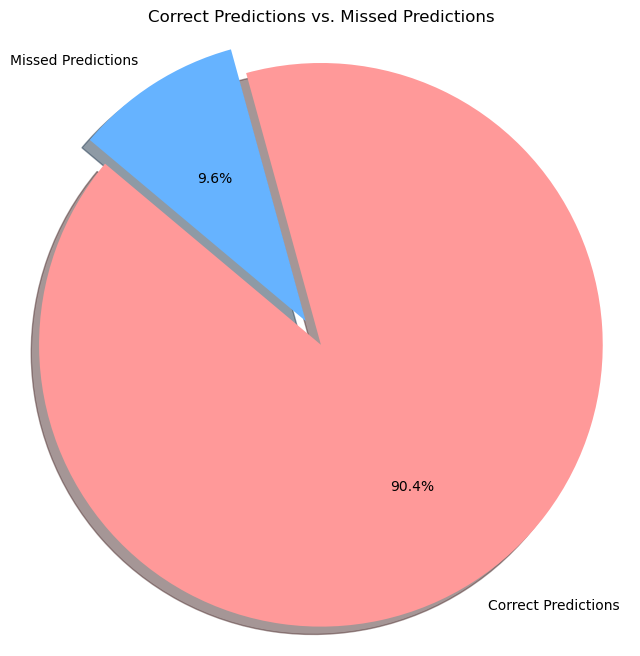

In [51]:
# Create pie chart to show how many pairs splink got right
import matplotlib.pyplot as plt

# Calculate the number of common pairs and non-matching pairs
correct_predictions = len(common_pairs)
missed_predictions = (len(true_matches_set) - len(common_pairs))

# Data for the pie chart
labels = ['Correct Predictions', 'Missed Predictions']
sizes = [correct_predictions, missed_predictions]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # explode the first slice

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.title('Correct Predictions vs. Missed Predictions')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Display the pie chart
plt.show()

In [35]:
# Note: Splink's function number_of_comparisons_to_be_scored_post_filter_conditions says it did 37 comparison
# but the numbers do not add up and also I filtered down more by match_weight and match_probability so it is 
# difficult to determine confusion matrix without knowing for sure the total amount of comparisons done

# TO DO: figure out how many total comparisons were made by Splink

# List parameters and numbers used:
# 52 true matches (ground truth)


# Confusion Matrix Notes: 
# True Positives: 47 (splink predicted correctly that these were same entity)
# False Positives: 18 (splink thought it was same entity but it was not)
# True Negative:  (splink is right that two rows are not the same entity)
# False Negative:  (splink is wrong and thinks that two rows are not same entity but they are)


# P = total number of positive instances (ground truth entities manually created in dataset)
#   = true_matches_set
#   = 52
# N = total number of negative instances, 1000 - 52 = 948
#   = 948
# True Positives: TP = P – FN  
#   = common_pairs
# False Positives: FP = N - TN
# True Negatives: TN = N - (TP + FP + FN) 
# False Negatives: FN = P - TP

# Calculate False Positives

In [56]:
# Calculate False Positives
# Predictions - true matches
false_positives = predictions_set.difference(true_matches_set)
false_positives

{(4, 483),
 (12, 99),
 (18, 173),
 (48, 124),
 (62, 988),
 (75, 996),
 (124, 892),
 (154, 525),
 (188, 632),
 (236, 868),
 (277, 877),
 (280, 741),
 (360, 819),
 (427, 675),
 (549, 660),
 (708, 860),
 (767, 801),
 (789, 868)}

In [58]:
# Count number of false positives
false_positive_count = len(false_positives)
false_positive_count
print(f"False Positive count = {false_positive_count}")

False Positive count = 18


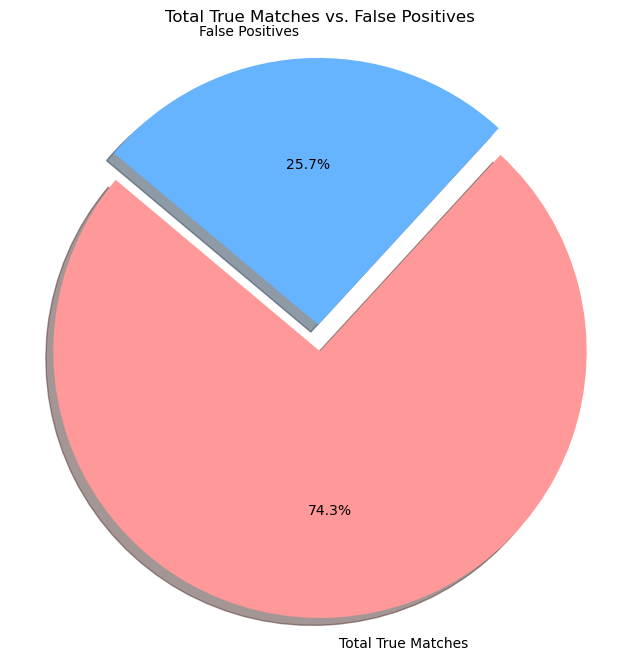

In [59]:
# Create pie chart to show how many pairs splink got right
import matplotlib.pyplot as plt

# Calculate the number of common pairs and non-matching pairs
total_true_matches = len(true_matches_set)
false_positives = false_positive_count

# Data for the pie chart
labels = ['Total True Matches', 'False Positives']
sizes = [total_true_matches, false_positives]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # explode the first slice

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.title('Total True Matches vs. False Positives')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Display the pie chart
plt.show()

In [27]:
# Reasons for false positives: 
# sender has same first and last name but the rest of the information in row is different
# same first initial for first name and same full last name, but all other info in row is different

# Calculate true negatives

In [32]:
# True Negatives (TN): Pairs correctly identified as non-matches.
# true negatives = splink is right that two rows are not the same entity
# Using splink metrics and own parameters set, true negatives will be rows with match_weights < 0 AND
# match_probability < 0.5
# (TN) = N - (TP + FP + FN) 
# N = total number of instances = 1000

In [34]:
# Example, can't calculate now because it is unclear the value of N is unclear now, or the total number of instances
# splink compared
# Sample data
N = 200  # Total number of instances
TP = 50
FP = 30
FN = 20

# Calculate True Negatives
TN = N - (TP + FP + FN)

# Display the result
print(f"True Negatives (TN): {TN}")

True Negatives (TN): 100


In [73]:
# Find the intersection of the sets to see if any predicted non-matches are in true_match_set
intersection_set = predictions_non_matches_set.intersection(true_matches_set)
intersection_set

{(907, 957), (925, 975), (934, 984)}

In [74]:
# Out of 52 true matches, splink thought 3 of them were non-matches when they actually were matches
# true negatives = 49 out the 52 true matches
# 49/52 = 94.23% of true negatives are correct
# 3/52 = 5.8% were incorrect true negatives

# True Negatives

In [76]:
# Calculate true negatives from set that splink predicted were not matches
true_negatives = predictions_non_matches_set.difference(true_matches_set)
true_negatives

{(7, 231),
 (8, 873),
 (17, 813),
 (19, 386),
 (20, 130),
 (22, 843),
 (43, 452),
 (53, 391),
 (56, 872),
 (64, 716),
 (71, 619),
 (77, 152),
 (88, 353),
 (98, 685),
 (105, 762),
 (107, 180),
 (118, 895),
 (125, 781),
 (128, 765),
 (135, 969),
 (142, 331),
 (144, 385),
 (159, 879),
 (171, 587),
 (188, 446),
 (189, 266),
 (191, 257),
 (194, 418),
 (203, 622),
 (210, 519),
 (221, 694),
 (238, 253),
 (262, 890),
 (263, 603),
 (285, 724),
 (288, 843),
 (289, 730),
 (293, 740),
 (302, 736),
 (309, 452),
 (311, 751),
 (325, 547),
 (342, 392),
 (345, 560),
 (347, 793),
 (349, 533),
 (356, 387),
 (388, 783),
 (389, 977),
 (395, 773),
 (399, 773),
 (411, 431),
 (414, 599),
 (415, 863),
 (432, 788),
 (434, 718),
 (437, 785),
 (457, 684),
 (459, 684),
 (464, 520),
 (465, 656),
 (479, 623),
 (498, 630),
 (502, 512),
 (507, 683),
 (516, 575),
 (518, 792),
 (526, 865),
 (531, 541),
 (537, 546),
 (539, 874),
 (563, 726),
 (574, 738),
 (583, 721),
 (595, 785),
 (644, 806),
 (655, 831),
 (676, 812),
 (

In [79]:
# Count of true negatives out of filtered set the splink believed are non-matches with set parameters
true_negative_count = len(true_negatives)
print(f"Number of true negatives out of set of predicted non-matches: {true_negative_count}")

Number of true negatives out of set of predicted non-matches: 85


# Find splink's predicted non-matches with chosen parameters

In [29]:
# Filter the DataFrame to keep only rows with match_weight < 0
match_weight_predictions_below_zero = predictions[predictions['match_weight'] < 0]
match_weight_predictions_below_zero

,match_weight,match_probability,unique_id_l,unique_id_r,sender_first_name_l,sender_first_name_r,sender_last_name_l,sender_last_name_r,sender_address_full_l,sender_address_full_r,match_key
2,-0.502287,0.413829,107,180,Joshua,Jessica,Blake,Blake,United States,United States,1
3,-1.779011,0.225636,7,231,Robert,Christopher,Price,Price,"561 Robles Loop, Thomasville, PA 72004",NaN,1
4,-0.502287,0.413829,88,353,William,Kimberly,Olson,Olson,United States,United States,1
5,-0.502287,0.413829,144,385,Christopher,Jeremy,Dickerson,Dickerson,United States,United States,1
6,-1.779011,0.225636,19,386,Monica,Nicole,Peters,Peters,NaN,United States,1
...,...,...,...,...,...,...,...,...,...,...,...
140,-1.672212,0.238833,43,452,Mason,Isabel,Stevenson,Stevenson,United States,United States,1
146,-0.836380,0.358994,745,991,Javier,J,Hernandez,Hernandez,NaN,Thailand,1
153,-0.620685,0.394072,142,331,Madison,Marissa,Johnson,Johnson,United States,United States,0
154,-0.793690,0.365831,64,716,Jamie,James,Miller,Miller,Reunion,United States,0


In [41]:
# Filter df further to keep only rows with match_probability below 0.5
splink_predictions_non_matches_df = match_weight_predictions_below_zero[match_weight_predictions_below_zero['match_probability'] < 0.5]
splink_predictions_non_matches_df

,match_weight,match_probability,unique_id_l,unique_id_r,sender_first_name_l,sender_first_name_r,sender_last_name_l,sender_last_name_r,sender_address_full_l,sender_address_full_r,match_key
2,-0.502287,0.413829,107,180,Joshua,Jessica,Blake,Blake,United States,United States,1
3,-1.779011,0.225636,7,231,Robert,Christopher,Price,Price,"561 Robles Loop, Thomasville, PA 72004",NaN,1
4,-0.502287,0.413829,88,353,William,Kimberly,Olson,Olson,United States,United States,1
5,-0.502287,0.413829,144,385,Christopher,Jeremy,Dickerson,Dickerson,United States,United States,1
6,-1.779011,0.225636,19,386,Monica,Nicole,Peters,Peters,NaN,United States,1
...,...,...,...,...,...,...,...,...,...,...,...
140,-1.672212,0.238833,43,452,Mason,Isabel,Stevenson,Stevenson,United States,United States,1
146,-0.836380,0.358994,745,991,Javier,J,Hernandez,Hernandez,NaN,Thailand,1
153,-0.620685,0.394072,142,331,Madison,Marissa,Johnson,Johnson,United States,United States,0
154,-0.793690,0.365831,64,716,Jamie,James,Miller,Miller,Reunion,United States,0


In [ ]:
# Make a dictionary for the splink's predictions of non-matches from splink_predictions_non_matches_df
predictions_non_matches = dict(zip(splink_predictions_non_matches_df['unique_id_l'], splink_predictions_non_matches_df['unique_id_r']))
predictions_non_matches

In [72]:
# Convert dictionary to set of tuples where each tuple contains the key and value
predictions_non_matches_set = set((min(k, v), max(k, v)) for k, v in predictions_non_matches.items())
predictions_non_matches_set

{(7, 231),
 (8, 873),
 (17, 813),
 (19, 386),
 (20, 130),
 (22, 843),
 (43, 452),
 (53, 391),
 (56, 872),
 (64, 716),
 (71, 619),
 (77, 152),
 (88, 353),
 (98, 685),
 (105, 762),
 (107, 180),
 (118, 895),
 (125, 781),
 (128, 765),
 (135, 969),
 (142, 331),
 (144, 385),
 (159, 879),
 (171, 587),
 (188, 446),
 (189, 266),
 (191, 257),
 (194, 418),
 (203, 622),
 (210, 519),
 (221, 694),
 (238, 253),
 (262, 890),
 (263, 603),
 (285, 724),
 (288, 843),
 (289, 730),
 (293, 740),
 (302, 736),
 (309, 452),
 (311, 751),
 (325, 547),
 (342, 392),
 (345, 560),
 (347, 793),
 (349, 533),
 (356, 387),
 (388, 783),
 (389, 977),
 (395, 773),
 (399, 773),
 (411, 431),
 (414, 599),
 (415, 863),
 (432, 788),
 (434, 718),
 (437, 785),
 (457, 684),
 (459, 684),
 (464, 520),
 (465, 656),
 (479, 623),
 (498, 630),
 (502, 512),
 (507, 683),
 (516, 575),
 (518, 792),
 (526, 865),
 (531, 541),
 (537, 546),
 (539, 874),
 (563, 726),
 (574, 738),
 (583, 721),
 (595, 785),
 (644, 806),
 (655, 831),
 (676, 812),
 (

In [65]:
# Calculate the number of non-matches splink predicted
non_match_count = len(predictions_non_matchs_set)
print(f"Number of non-matches splink calculated: {non_match_count}")

Number of non-matches splink calculated: 88


# False negatives

In [ ]:
# False Negatives (FN): Pairs incorrectly identified as non-matches.
# If you know the total number of positive instances (P), you can calculate false negatives as: 
# P = TP + FN

In [80]:
false_negatives = predictions_non_matches_set.intersection(true_matches_set)
false_negatives

{(907, 957), (925, 975), (934, 984)}

In [81]:
# False negatives = 3/52 = 5.7% of the 52 total matches ( not from total comparisons)